In [25]:
import pandas as pd

df = pd.read_csv("data/penguins_cleaned.csv")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181,3750,male
1,Adelie,Torgersen,39.5,17.4,186,3800,female
2,Adelie,Torgersen,40.3,18.0,195,3250,female
3,Adelie,Torgersen,36.7,19.3,193,3450,female
4,Adelie,Torgersen,39.3,20.6,190,3650,male


In [26]:
import scipy.stats as stats

r,p = stats.pearsonr(df["body_mass_g"], df["bill_length_mm"])
r2 = r**2

Text(0.5, 1.0, 'Scatterplot of body mass correlation with bill lenght')

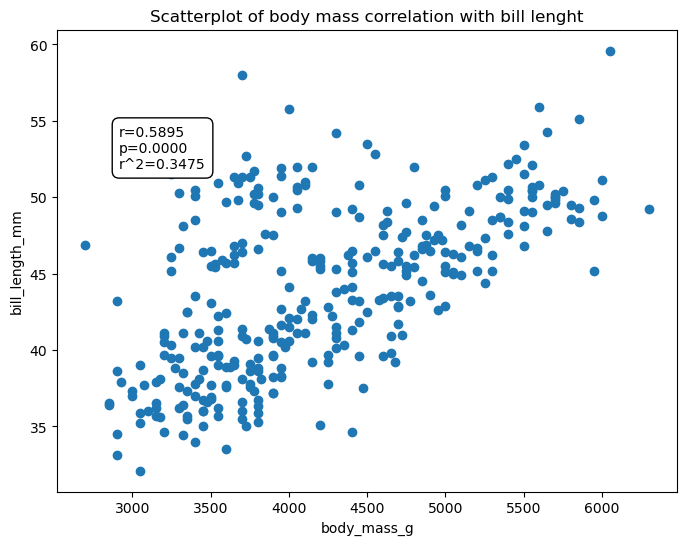

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
text = f"""r={r:.4f}
p={p:.4f}
r^2={r2:.4f}"""
plt.scatter(df["body_mass_g"], df["bill_length_mm"])
plt.xlabel("body_mass_g")
plt.ylabel("bill_length_mm")
plt.text(
    0.1, 
    0.7,
    text,
    transform=plt.gca().transAxes,
    bbox={"boxstyle":"round, pad =0.5", "fc":"white"}
    
)
plt.title("Scatterplot of body mass correlation with bill lenght")

<Axes: xlabel='body_mass_g', ylabel='bill_length_mm'>

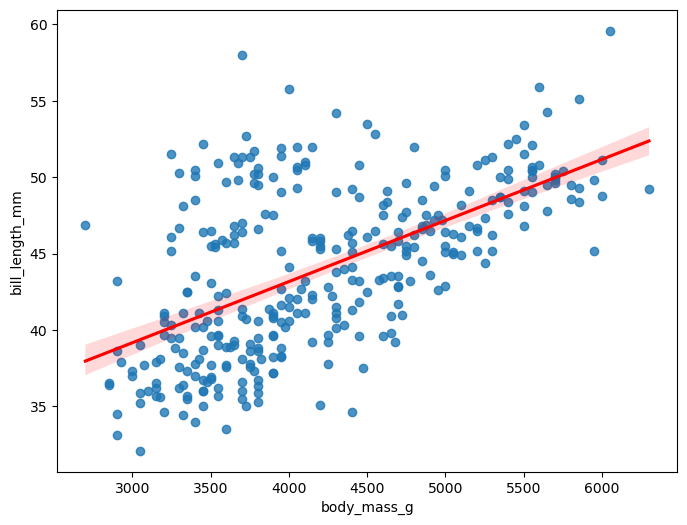

In [28]:

import seaborn as sns
plt.figure(figsize=(8,6))
sns.regplot(
    data=df, 
    x="body_mass_g", 
    y="bill_length_mm",
    line_kws={"color":"red", "label":"line of best fit."})




In [29]:
stats.linregress(df["body_mass_g"], df["bill_length_mm"])


LinregressResult(slope=np.float64(0.004003290320414924), intercept=np.float64(27.150721998842982), rvalue=np.float64(0.5894511101769487), pvalue=np.float64(1.538613514486092e-32), stderr=np.float64(0.0003015513851122659), intercept_stderr=np.float64(1.291603212343723))

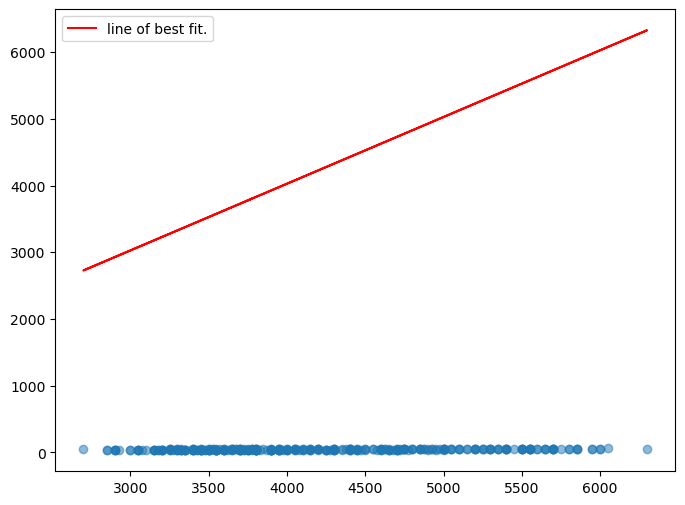

In [30]:
m,b,r_val, p_val, err = stats.linregress(df["body_mass_g"], df["bill_length_mm"])
line = df["body_mass_g"]+b
plt.figure(figsize=(8,6))
plt.scatter(df["body_mass_g"], df["bill_length_mm"], alpha=0.5)
plt.plot(df["body_mass_g"], line, color="red", label="line of best fit.")
plt.legend()
plt.show()


ValueError: x and y must have same first dimension, but have shapes (68,) and (333,)

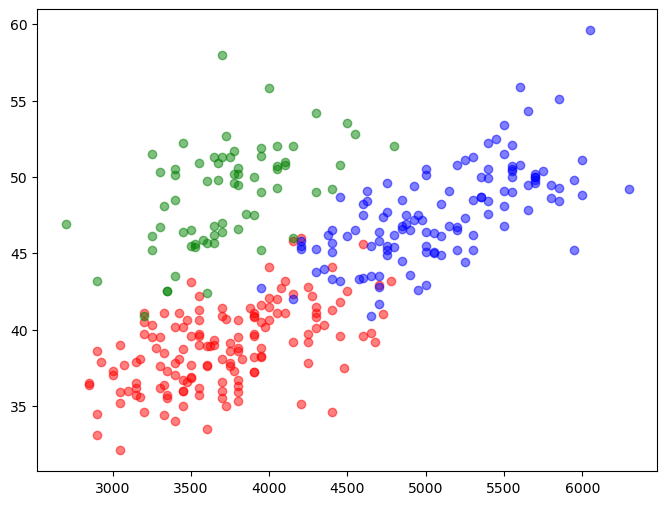

In [34]:
plt.figure(figsize=(8,6))
colors = ["red", "blue", "green"]   
for species in df["species"].unique():
    subset = df[df["species"]==species]
    x = subset["body_mass_g"]
    y = subset["bill_length_mm"]
    plt.scatter(x, y, alpha=0.5, label=species, color=colors.pop(0))
plt.plot(x, line, color="red", label="line of best fit.")
plt.legend()
plt.show()